<a href="https://colab.research.google.com/github/amatullahaloula/lab-3-feedforward-networks/blob/main/Section1_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process


**Due Date:** 28th July, 2026

**Format:** Jupyter Notebook / Google Colab



**Student Name:** Na'ima Mohamet Aloula

**Student ID:** 30722027

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end i should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

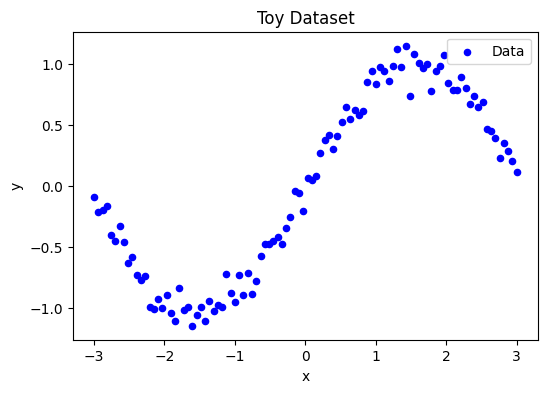

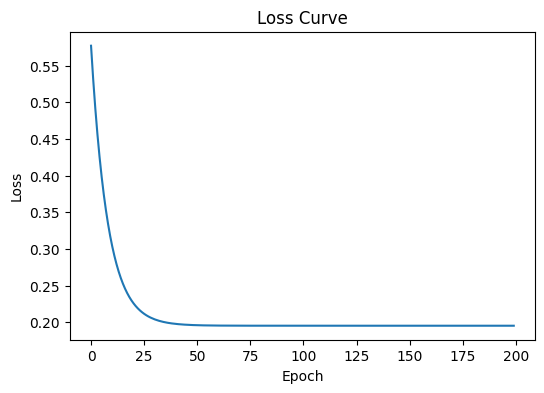

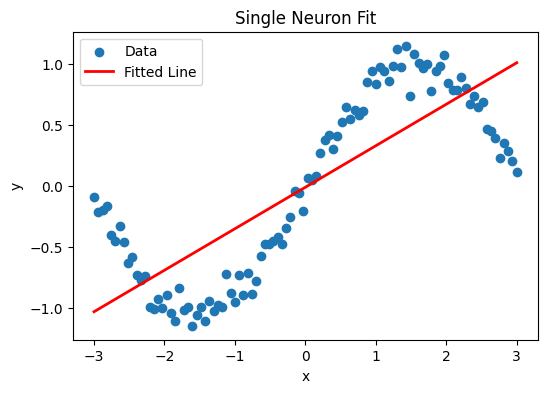

Final weight: 0.33903169126186905
Final bias: -0.010275989913865108
Final loss: 0.1954518094384745


In [ ]:
# Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Plot the toy data
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='blue', s=20, label='Data')
plt.title("Toy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Initialise parameters
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# Hyperparameters
lr = 0.01
epochs = 200

losses = []

# Gradient Descent
for epoch in range(epochs):

    # Forward pass
    y_hat = w * x + b

    # Mean Squared Error
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update parameters
    w -= lr * dw
    b -= lr * db

# Plot loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Plot fitted line
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, w*x + b, color="red", linewidth=2, label="Fitted Line")
plt.title("Single Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print("Final weight:", w)
print("Final bias:", b)
print("Final loss:", losses[-1])

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
1 The Mean Squared Error is

L = (1/n) Σ(ŷ − y)²

Since ŷ = wx + b,

dL/dw = (1/n) Σ 2(ŷ − y)x

This is exactly the same equation used in the code:

dw = np.mean(2 * (y_hat - y) * x)

Therefore, the mathematical derivation matches the implementation.

2  This is underfitting.

A single neuron can only learn a straight-line relationship because its output is y = wx + b.

A sine wave is a non-linear function with many curves and turning points. No matter how long the model trains, it cannot represent the shape of a sine wave using only one weight and one bias. More neurons and non-linear activation functions are needed to learn this pattern.

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. A linear layer computes y = Wx + b. If two linear layers are stacked together, the result is still a linear function because the two weight matrices can be multiplied into one equivalent matrix. Therefore, multiple linear layers without an activation function are mathematically equivalent to a single linear layer and cannot model complex non-linear relationships.

2. The hidden layer's eight neurons learned different non-linear features of the input. Together, these features combined to approximate the curved shape of the sine wave much better than a single neuron.

3. Backpropagation is the process of computing the gradients of the loss with respect to every parameter in the network and using those gradients to update the weights during training.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

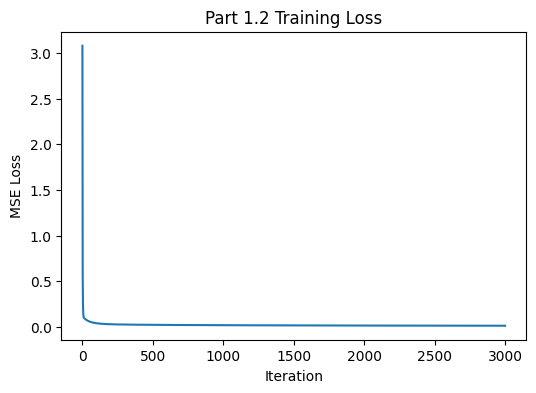

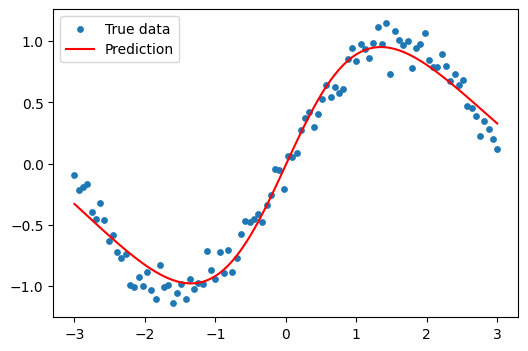

In [ ]:
# Part 1.2
# Hidden layer neural network trained completely by hand

np.random.seed(RANDOM_STATE)

X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)

# Parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((8,))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1,))

learning_rate = 0.05
losses = []

for step in range(3000):

    # Forward pass
    z1 = X @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - Y) ** 2)
    losses.append(loss)

    # Backward pass
    dloss = 2 * (y_hat - Y) / len(Y)

    dW2 = h.T @ dloss
    db2 = np.sum(dloss, axis=0)

    dh = dloss @ W2.T
    dz1 = dh * (1 - h**2)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0)

    # Gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Part 1.2 Training Loss")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(X, Y, s=15, label="True data")
plt.plot(X, y_hat, color="red", label="Prediction")
plt.legend()
plt.show()

1. Why do multiple linear layers collapse into one?

Each linear layer performs a linear transformation. When several linear layers are stacked without an activation function, they can be combined into one single linear equation. Therefore, the network is still only able to learn a linear relationship, regardless of how many layers it has.

2. What role did the 8 hidden neurons play?

The hidden neurons learned different nonlinear features of the input. After applying the tanh activation, each neuron responds differently to different regions of the data. Together they allow the network to model the curved relationship much better than a single neuron.

3. What is backpropagation?

Backpropagation is the process of calculating the gradient of the loss with respect to every parameter by applying the chain rule, allowing gradient descent to update the weights and reduce the error.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_38693/2593821399.py:24: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
/tmp/ipykernel_38693/2593821399.py:33: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_38693/2593821399.py:34: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


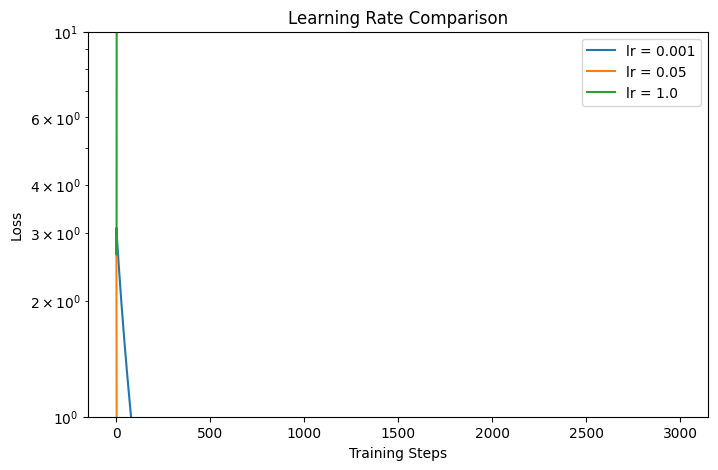

In [ ]:
def train_toy(lr, steps=3000):
    # Reset seed so all runs start from the same weights
    np.random.seed(RANDOM_STATE)

    # Prepare data
    X = x.reshape(-1, 1)
    Y = y.reshape(-1, 1)

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((8,))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1,))

    losses = []

    for step in range(steps):

        # Forward pass
        z1 = X @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - Y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - Y) / len(Y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update parameters
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


# Train with three learning rates
loss_lr1 = train_toy(0.001)
loss_lr2 = train_toy(0.05)
loss_lr3 = train_toy(1.0)

# Plot comparison
plt.figure(figsize=(8,5))

plt.plot(loss_lr1, label="lr = 0.001")
plt.plot(loss_lr2, label="lr = 0.05")
plt.plot(loss_lr3, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**
The learning rate controls how much the model updates its weights during each training step.

Learning rate = 0.001: The loss decreases very slowly because the weight updates are very small. The model learns, but it takes many iterations.
Learning rate = 0.05: The loss decreases smoothly and reaches a low value much faster. This learning rate provides a good balance between speed and stability.
Learning rate = 1.0: The loss becomes unstable and may oscillate or increase instead of decreasing. This happens because the updates are too large, causing the model to overshoot the minimum loss repeatedly rather than converging to it.

A learning rate that is too large does not make learning faster. Instead, it causes the optimisation process to jump back and forth around the minimum or even diverge, preventing the model from finding the best solution.